# SAR Sea-Ice Drift NetCDF Layer Viewer
This notebook provides a guided introduction to working with the NOAA PolarWatch 
SAR daily sea-ice drift NetCDF product. It covers opening and inspecting the 
dataset structure, interpreting CF-compliant metadata and coordinate variables, 
visualizing drift vectors as quiver plots on a polar stereographic map 
(EPSG:3413), and exporting the data to compressed NumPy arrays for downstream 
analysis in pandas and other libraries.

## Python libraries
Here is the installation for the libaries needed to process the data. If any libraries fail loading in the `load libraries` cell, revist what needs to be installed in `install libraries` cell. The installation only needs to run once. The requirements.txt will have all of the necessary libraries, this step confirms `Requirement already satisfied`



### Install libraries
Change cell below to `Code` from `Raw NBConvert` to execute

### Load libraries
Note:
if you see a warning `UserWarning: pyproj unable to set database path.`, it is okay to ignore. The warning is raised setting a path on the local machine.
It has not impact on the ability to use the library. The path functions prior to calling the `pyproj` library aims to fix the issue, but it doesn't always work.

In [1]:
import os
import sys
from pathlib import Path

# Derive paths from the active env rather than hard-coding
env_prefix = Path(sys.prefix)
proj_dir = env_prefix / "Library" / "share" / "proj"
bin_dir = env_prefix / "Library" / "bin"

os.add_dll_directory(str(bin_dir))

# Set both env vars for PROJ
os.environ["PROJ_DATA"] = str(proj_dir)
os.environ["PROJ_LIB"] = str(proj_dir)   # backward compatibility

# Tell pyproj explicitly where proj.db lives
from pyproj.datadir import set_data_dir
set_data_dir(str(proj_dir))

from pyproj import Transformer

import xarray as xr
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
from shapely.geometry import LineString
import sqlite3

SPEED_PRECISION = 3
SECONDS_PER_DAY = 24 * 60 * 60
OUTLIER_COLORS = {
    '00': (0.906, 0.443, 0.282),  # rgb(231,113,72)  - No outlier, under threshold
    '01': (0.000, 1.000, 0.000),  # rgb(0,255,0)     - No outlier, above threshold
    '10': (1.000, 0.000, 0.000),  # rgb(255,0,0)     - Distance outlier, under
    '11': (1.000, 0.000, 0.000),  # rgb(255,0,0)     - Distance outlier, above
    '20': (0.000, 0.000, 1.000),  # rgb(0,0,255)     - Bearing outlier, under
    '21': (0.000, 0.000, 1.000),  # rgb(0,0,255)     - Bearing outlier, above
    '30': (1.000, 1.000, 0.000),  # rgb(255,255,0)   - Mahalanobis, under
    '31': (1.000, 1.000, 0.000),  # rgb(255,255,0)   - Mahalanobis, above
    '40': (0.502, 0.000, 0.502),  # rgb(128,0,128)   - Distance+bearing, under
    '41': (0.502, 0.000, 0.502),  # rgb(128,0,128)   - Distance+bearing, above
    '50': (1.000, 0.502, 0.000),  # rgb(255,128,0)   - Mahal+distance, under
    '51': (1.000, 0.502, 0.000),  # rgb(255,128,0)   - Mahal+distance, above
    '60': (0.302, 0.302, 0.702),  # rgb(77,77,179)   - Mahal+bearing, under
    '61': (0.302, 0.302, 0.702),  # rgb(77,77,179)   - Mahal+bearing, above
    '70': (0.000, 0.000, 0.000),  # rgb(0,0,0)       - Mahal+dist+bearing, under
    '71': (0.000, 0.000, 0.000),  # rgb(0,0,0)       - Mahal+dist+bearing, above
}

C:\ProgramData\anaconda3\envs\noaa_ml\lib\site-packages\pyproj\__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [2]:
def extract_values(layer, has_outliers):
    """
    Extract and flatten all drift vector values from a single NetCDF time layer.

    Takes an xarray Dataset time slice, builds a meshgrid of projected
    start positions (X1, Y1) from the x/y coordinate arrays, computes end
    positions (X2, Y2) from the displacement variables, derives additional
    columns (velocity components, distance, speed in km/day), and
    reprojects all positions to EPSG:4326. All 2D arrays are then flattened
    and masked to valid (finite sea_ice_speed) observations only.

    Args:
        layer (xarray.Dataset): A single time slice selected via
            `ds.isel(time=n)`. Expected variables:
                - 'layer_id' (str coordinate): Source file pair identifier.
                - 'time_bnds' (float64, shape (2,)): Start and end times
                  in seconds since 2000-01-01.
                - 'x', 'y' (float64): 1D projected coordinate arrays (m,
                  EPSG:3413).
                - 'sea_ice_x_displacement' (float32, y x x): X displacement (m).
                - 'sea_ice_y_displacement' (float32, y x x): Y displacement (m).
                - 'sea_ice_speed' (float32, y x x): Drift speed (m s⁻¹).
                  Used as the valid data mask (finite values only).
                - 'direction_of_sea_ice_displacement' (float32, y x x):
                  Drift bearing (degrees).
                - 'outlier_category' (int16, y x x): Outlier classification
                  code. Only read when `has_outliers=True`.
        has_outliers (bool): If True, extract and zero-pad outlier_category
            values to two-digit strings (e.g. 0 -> '00', 1 -> '01', 10 ->
            '10') for compatibility with OUTLIER_COLORS and the QGIS QML
            style. If False, outlier_category is set to the scalar -9.

    Returns:
        dict: Flattened 1D arrays (one entry per valid observation) with
            the following keys:
                - 'layer_id' (str): Source file pair identifier.
                - 'date_start' (str): Start datetime ('YYYY-MM-DD HH:MM:SS').
                - 'date_end' (str): End datetime ('YYYY-MM-DD HH:MM:SS').
                - 'Lon1', 'Lat1' (ndarray): Start longitude/latitude (EPSG:4326, degrees).
                - 'Lon2', 'Lat2' (ndarray): End longitude/latitude (EPSG:4326, degrees).
                - 'X1', 'Y1' (ndarray): Start projected coordinates (m, EPSG:3413).
                - 'X2', 'Y2' (ndarray): End projected coordinates (m, EPSG:3413).
                - 'duration_s' (float): Observation duration in seconds (scalar).
                - 'dx', 'dy' (ndarray): X/Y displacement components (m).
                - 'u_ms', 'v_ms' (ndarray): X/Y velocity components (m s⁻¹),
                  rounded to SPEED_PRECISION decimal places.
                - 'speed' (ndarray): Drift speed (m s⁻¹), rounded to
                  SPEED_PRECISION decimal places.
                - 'speed_kmdy' (ndarray): Drift speed (km day⁻¹), rounded to
                  SPEED_PRECISION decimal places.
                - 'direction' (ndarray): Drift bearing (degrees), rounded to 0
                  decimal places.
                - 'distance' (ndarray): Geodesic displacement distance (m),
                  rounded to SPEED_PRECISION decimal places.
                - 'outlier_category' (ndarray of str or int): Two-digit
                  zero-padded outlier codes if `has_outliers=True`, otherwise
                  the scalar -9.

    Notes:
        - End positions are computed as X2 = X1 + dx, Y2 = Y1 + dy in
          EPSG:3413 projected space.
        - Rounding precision for speed-derived values is controlled by the
          module-level constant SPEED_PRECISION.
        - Speed conversion to km/day uses the module-level constant
          SECONDS_PER_DAY.
    """    
    
    # layer id
    layer_id = str(layer['layer_id'].values)


    # time
    epoch = pd.Timestamp('2000-01-01')
    date_start = epoch + pd.to_timedelta(
        float(layer['time_bnds'].values[0]), unit='s'
    )
    date_end = epoch + pd.to_timedelta(
        float(layer['time_bnds'].values[1]), unit='s'
    )
    duration_s = (date_end - date_start).total_seconds()


    # meshgrid: X1, Y1 for every grid cell
    y_coords = layer['y'].values
    x_coords = layer['x'].values
    X1, Y1 = np.meshgrid(x_coords, y_coords)


    # supplied data values
    dx = layer['sea_ice_x_displacement'].values
    dy = layer['sea_ice_y_displacement'].values
    X2 = X1 + dx
    Y2 = Y1 + dy
    speed = layer['sea_ice_speed'].values
    direction = layer['direction_of_sea_ice_displacement'].values

    
    # derived data values
    u_ms = dx / duration_s
    v_ms = dy / duration_s
    distance = speed * duration_s
    speed_kmdy = (distance / 1000) / (duration_s / SECONDS_PER_DAY)


    # add projection
    transformer = Transformer.from_crs('EPSG:3413', 'EPSG:4326', always_xy=True)
    lon1, lat1 = transformer.transform(X1, Y1)
    lon2, lat2 = transformer.transform(X2, Y2)
    
    
    # flatten and mask to valid cells only
    valid_mask = np.isfinite(speed)
    X1_valid = X1[valid_mask]
    Y1_valid = Y1[valid_mask]
    X2_valid = X2[valid_mask]
    Y2_valid = Y2[valid_mask]
    dx_valid = dx[valid_mask]
    dy_valid = dy[valid_mask]
    speed_valid = np.round(speed[valid_mask], SPEED_PRECISION)
    direction_valid = np.round(direction[valid_mask], 0)
    lon1_valid, lat1_valid = lon1[valid_mask], lat1[valid_mask]
    lon2_valid, lat2_valid = lon2[valid_mask], lat2[valid_mask]
    u_ms_valid = np.round(u_ms[valid_mask], SPEED_PRECISION)
    v_ms_valid = np.round(v_ms[valid_mask], SPEED_PRECISION)
    distance_valid = np.round(distance[valid_mask], SPEED_PRECISION)
    speed_kmdy_valid = np.round(speed_kmdy[valid_mask], SPEED_PRECISION)
    if has_outliers:
        outlier_valid = layer['outlier_category'].values[valid_mask]
        outlier_valid = np.array([f'{int(v):02d}' for v in outlier_valid]) # zero pad for qml styles and PNG labels
    else:
        outlier_valid = -9
        
        
    return {
        'layer_id': layer_id,
        'date_start': date_start.strftime('%Y-%m-%d %H:%M:%S'),
        'date_end': date_end.strftime('%Y-%m-%d %H:%M:%S'),
        'Lon1': lon1_valid,
        'Lat1': lat1_valid,
        'Lon2': lon2_valid,
        'Lat2': lat2_valid,
        'X1': X1_valid,
        'Y1': Y1_valid,
        'X2': X2_valid,
        'Y2': Y2_valid,
        'duration_s': duration_s,
        'dx': dx_valid,
        'dy': dy_valid,
        'u_ms': u_ms_valid,
        'v_ms': v_ms_valid,
        'speed': speed_valid,
        'speed_kmdy': speed_kmdy_valid,
        'direction': direction_valid,
        'distance':  distance_valid,
        'outlier_category': outlier_valid,
    }

In [3]:
def layer_to_gpkg(layer_values, has_outliers):
    """
    Export a single sea-ice drift layer to a GeoPackage file with an
    embedded QGIS style.

    Builds a LineString geometry for each valid observation from projected
    start (X1, Y1) to end (X2, Y2) coordinates in EPSG:3413, constructs a
    GeoDataFrame with all drift attributes, writes it to a GeoPackage file
    in the 'layer_to_gpkg/' directory, and embeds the appropriate QGIS QML
    style via `_embed_qml_style`.

    The output filename is derived from `layer_values['layer_id']`.
    
    Args:
        layer_values (dict): Output of `extract_values()`. Required keys:
            - 'layer_id' (str): Used as the output filename stem.
            - 'Lon1', 'Lat1' (ndarray): Start longitude/latitude (EPSG:4326, degrees).
            - 'Lon2', 'Lat2' (ndarray): End longitude/latitude (EPSG:4326, degrees).
            - 'X1', 'Y1' (ndarray): Start projected coordinates (m, EPSG:3413).
            - 'X2', 'Y2' (ndarray): End projected coordinates (m, EPSG:3413).
            - 'date_start', 'date_end' (str): Observation start/end datetimes.
            - 'duration_s' (float): Observation duration in seconds.
            - 'dx', 'dy' (ndarray): X/Y displacement components (m).
            - 'u_ms', 'v_ms' (ndarray): X/Y velocity components (m s⁻¹).
            - 'speed' (ndarray): Drift speed (m s⁻¹).
            - 'speed_kmdy' (ndarray): Drift speed (km day⁻¹).
            - 'direction' (ndarray): Drift bearing (degrees).
            - 'distance' (ndarray): Geodesic displacement distance (m).
            - 'outlier_category' (ndarray of str or int): Two-digit
              zero-padded outlier codes if `has_outliers=True`, otherwise -9.
        has_outliers (bool): Controls which QGIS QML style is embedded:
            - True:  'meta/outlier_style.qml' — categorical colors per
              outlier code.
            - False: 'meta/graduated_quivers.qml' — graduated color ramp
              by speed or magnitude.

    Returns:
        None

    Output:
        GeoPackage file written to 'layer_to_gpkg/<layer_id>.gpkg' with a
        single layer named 'drift_lines' in EPSG:3413. The embedded QML
        style allows the file to render correctly when opened directly in
        QGIS.
    """    
    
    # decide which quiver style to use based on if the layer has outliers
    if has_outliers:
        quiver_style = r'meta/outlier_style.qml'
    else:
        quiver_style = r'meta/graduated_quivers.qml'
    if not os.path.exists(quiver_style):
        raise ValueError(f'{quiver_style} file not located. Please be sure to download contents of `meta` folder in GitHub.')

    # build geometries from flat scalar arrays
    locations = zip(layer_values['X1'], layer_values['Y1'], layer_values['X2'], layer_values['Y2'])
    geometries = [
        LineString([(x1, y1), (x2, y2)])
        for x1, y1, x2, y2 in locations
    ]
    gdf = gpd.GeoDataFrame(
        {
            'layer_id':                          layer_values['layer_id'],
            'longitude_1':                       layer_values['Lon1'],
            'latitude_1':                        layer_values['Lat1'],
            'longitude_2':                       layer_values['Lon2'],
            'latitude_2':                        layer_values['Lat2'],
            'X1':                                layer_values['X1'],
            'Y1':                                layer_values['Y1'],
            'X2':                                layer_values['X2'],
            'Y2':                                layer_values['Y2'],
            'date_start':                        layer_values['date_start'],
            'date_end':                          layer_values['date_end'],
            'duration_s':                        layer_values['duration_s'],
            'sea_ice_x_displacement':            layer_values['dx'],
            'sea_ice_y_displacement':            layer_values['dy'],
            'u_ms':                              layer_values['u_ms'],
            'v_ms':                              layer_values['v_ms'],
            'sea_ice_speed':                     layer_values['speed'],
            'sea_ice_speed_kmdy':                layer_values['speed_kmdy'],
            'direction_of_sea_ice_displacement': layer_values['direction'],
            'distance':                          layer_values['distance'],
            'outlier_category':                  layer_values['outlier_category'],
            'geometry_type':                     'line'
        },
        geometry=geometries,
        crs='EPSG:3413'
    )


    # Save as a single GeoPackage file (supports mixed geometries)
    if not os.path.exists('layer_to_gpkg'):
        os.makedirs('layer_to_gpkg', exists_ok=True)
    geopackage_file = f"{layer_id}.gpkg"
    output_file_path = os.path.join(
        'layer_to_gpkg', f"{geopackage_file}"
    )

    gdf = gdf.rename(
        columns={'geometry_line': 'geometry'}
    ).set_geometry('geometry')
    gdf = gdf.set_crs('EPSG:3413')
    gdf.to_file(output_file_path, layer='drift_lines', driver='GPKG')


    # embed .qml outlier layer style
    _embed_qml_style(output_file_path, 'drift_lines', quiver_style)

In [4]:
def create_png(layer_values, has_outliers):
    """
    Render a quiver plot of sea-ice drift vectors and display it inline.

    Vectors are plotted in EPSG:3413 (WGS84 North Polar Stereographic)
    using start positions (X1, Y1) and displacement components (dx, dy)
    from `layer_values`. The map extent is derived from the bounding box
    of all start and end positions with a fixed 300 km pad on each side.

    Arrow coloring has two modes controlled by `has_outliers`:
        - True: per-arrow colors matching the QGIS outlier_style.qml
          category definitions (OUTLIER_COLORS), with a legend showing
          only the outlier codes present in this layer. The legend
          includes a note explaining that '(under)' means below the
          neighbor threshold and '(above)' means at or above it.
        - False: viridis colormap scaled to displacement magnitude (m),
          with a colorbar labeled 'Displacement magnitude (m)'.

    Args:
        layer_values (dict): Output of `extract_values()`. Required keys:
            - 'X1', 'Y1' (ndarray): Projected start positions (m, EPSG:3413).
            - 'X2', 'Y2' (ndarray): Projected end positions (m, EPSG:3413).
            - 'dx', 'dy' (ndarray): X/Y displacement components (m).
            - 'speed' (ndarray): Sea-ice speed (m s⁻¹), used for
              observation count in the plot title.
            - 'outlier_category' (ndarray of str): Two-digit zero-padded
              outlier codes per observation (e.g. '00', '01', '10').
              Only required when `has_outliers=True`.
        has_outliers (bool): If True, color arrows by outlier category
            using OUTLIER_COLORS and render a categorical legend.
            If False, color by displacement magnitude using viridis
            and render a colorbar.

    Returns:
        None
    """
    # set projection
    crs_3413 = ccrs.NorthPolarStereo(
        central_longitude=-45,
        true_scale_latitude=70,
        globe=ccrs.Globe(datum='WGS84', ellipse='WGS84')
    )
    fig = plt.figure(figsize=(10, 10))
    ax = plt.axes(projection=crs_3413)

    X1_valid = layer_values['X1']
    Y1_valid = layer_values['Y1']
    X2_valid = layer_values['X2']
    Y2_valid = layer_values['Y2']
    dx       = layer_values['dx']
    dy       = layer_values['dy']

    # extent from full vector bounding box
    pad = 300_000  # 300 km
    xmin = np.round(min(X1_valid.min(), X2_valid.min()) - pad, 3)
    xmax = np.round(max(X1_valid.max(), X2_valid.max()) + pad, 3)
    ymin = np.round(min(Y1_valid.min(), Y2_valid.min()) - pad, 3)
    ymax = np.round(max(Y1_valid.max(), Y2_valid.max()) + pad, 3)

    ax.set_extent([xmin, xmax, ymin, ymax], crs=crs_3413)
    ax.add_feature(cfeature.LAND, zorder=0)
    ax.coastlines(resolution="10m", linewidth=1.0, zorder=1)

    if has_outliers:
        # outlier colors: derive code strings and colors before quiver call
        outlier_valid = layer_values['outlier_category']
        code_strs = [f'{int(c):02d}' for c in np.asarray(outlier_valid)]
        quiver_colors = [OUTLIER_COLORS.get(c, (0.5, 0.5, 0.5)) for c in code_strs]

        q = ax.quiver(
            X1_valid, Y1_valid, dx, dy,
            transform=crs_3413, angles="xy", scale_units="xy", scale=1,
            width=0.002, pivot="tail", color=quiver_colors, zorder=2
        )

        legend_labels = {
            '00': 'No outlier (under)',      '01': 'No outlier (above)',
            '10': 'Distance (under)',        '11': 'Distance (above)',
            '20': 'Bearing (under)',         '21': 'Bearing (above)',
            '30': 'Mahalanobis (under)',     '31': 'Mahalanobis (above)',
            '40': 'Dist+bearing (under)',    '41': 'Dist+bearing (above)',
            '50': 'Mahal+dist (under)',      '51': 'Mahal+dist (above)',
            '60': 'Mahal+bearing (under)',   '61': 'Mahal+bearing (above)',
            '70': 'Mahal+dist+bear (under)', '71': 'Mahal+dist+bear (above)',
        }
        unique_codes = sorted(set(code_strs))
        handles = [
            Patch(color=OUTLIER_COLORS[c], label=legend_labels.get(c, c))
            for c in unique_codes if c in OUTLIER_COLORS
        ]
        
        # explain `over` and `under`
        handles.append(Patch(color='none', label=''))
        handles.append(Patch(color='none', label='(under) = below neighbor\nthreshold'))
        handles.append(Patch(color='none', label='(above) = at or above neighbor\nthreshold'))

        ax.legend(handles=handles, loc='lower left', fontsize=8, framealpha=0.8)
        
    else:
        # viridis: color by displacement magnitude
        mag_valid = np.hypot(dx, dy)
        norm = mcolors.Normalize(vmin=mag_valid.min(), vmax=mag_valid.max())
        q = ax.quiver(
            X1_valid, Y1_valid, dx, dy, mag_valid,
            transform=crs_3413, angles="xy", scale_units="xy", scale=1,
            width=0.002, pivot="tail", cmap='viridis', norm=norm, zorder=2
        )
        cbar = fig.colorbar(q, ax=ax, orientation="vertical", shrink=0.65, pad=0.02)
        cbar.set_label("Displacement magnitude (m)")

        
    ax.set_title(
        f"Sea-ice Vector Velocities\n"
        f"x {xmin} to {xmax}; y {ymin} to {ymax}\n"
        f"Total observations: {len(layer_values['speed'])}\n"
        f"Polar stereographic EPSG:3413"
    )

    plt.show()

In [5]:
def _embed_qml_style(gpkg_path, layer_name, qml_path):
    """
    Embed a QML style into a GeoPackage's layer_styles table.

    Reads a QML file and writes its contents into the QGIS-standard
    layer_styles table inside the GeoPackage. QGIS will automatically
    apply the style when the layer is loaded, requiring no QML file
    on the end user's machine.

    Args:
        gpkg_path (str): Full path to the target GeoPackage file.
        layer_name (str): Name of the layer to apply the style to.
                          Must match the layer name in the GeoPackage exactly.
        qml_path (str): Full path to the QML style file to embed.

    Returns:
        None

    Notes:
        - The layer_styles table is created if it does not already exist,
          following the QGIS standard schema.
        - `f_geometry_column` is hardcoded to 'geom' because GeoPandas
          silently renames the geometry column from 'geometry' to 'geom'
          when writing to GeoPackage format.
        - `useAsDefault` is set to 1 so QGIS applies the style automatically
          on load without user intervention.
        - The layer_styles table is registered in gpkg_contents as an
          attributes layer for full GeoPackage spec compliance.
    """
    with open(qml_path, 'r') as f:
        qml_content = f.read()

    conn = sqlite3.connect(gpkg_path)
    cursor = conn.cursor()

    # Create layer_styles table if it doesn't exist (QGIS standard schema)
    cursor.execute("""
                   CREATE TABLE IF NOT EXISTS layer_styles (
                       id INTEGER PRIMARY KEY AUTOINCREMENT,
                       f_table_catalog TEXT,
                       f_table_schema TEXT,
                       f_table_name TEXT,
                       f_geometry_column TEXT,
                       styleName TEXT,
                       styleQML TEXT,
                       styleSLD TEXT,
                       useAsDefault INTEGER,
                       description TEXT,
                       owner TEXT,
                       ui TEXT,
                       update_time DATETIME DEFAULT CURRENT_TIMESTAMP
                )
                """
    )


    cursor.execute("""
                   INSERT INTO layer_styles 
                   (f_table_catalog, f_table_schema, f_table_name, 
                    f_geometry_column, styleName, styleQML, styleSLD,
                    useAsDefault, description, owner)
                   VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
                   """,
                   (
                       '',           # f_table_catalog
                       '',           # f_table_schema
                       layer_name,   # f_table_name  
                       'geom',       # f_geometry_column
                       'outliers',   # styleName
                       qml_content,  # styleQML
                       '',           # styleSLD (leave blank)
                       1,            # useAsDefault
                       '',
                       ''
                    )
    )
    
    cursor.execute("""
                   INSERT OR IGNORE INTO gpkg_contents 
                   (table_name, data_type, identifier, description,
                    last_change)
                   VALUES 
                   ('layer_styles', 'attributes', 'layer_styles',
                    'QGIS layer styles', datetime('now'))
                   """
    )

    conn.commit()    
    conn.close()

## Open NetCDF file and view summary

In [6]:
nc_path = r"SIVelocity_SAR/2/2024/nc/SIVelocity_SAR_20241230_20241231_scenes_12km_NH_3413.nc"
if not os.path.exists(nc_path):
    raise ValueError(f'Cannot locate file {nc_path}')
ds = xr.open_dataset(nc_path, decode_times=False, mask_and_scale=False)
ds

<xarray.Dataset> Size: 2GB
Dimensions:                            (time: 154, y: 896, x: 608, nv: 2)
Coordinates:
  * nv                                 (nv) int64 16B 0 1
  * x                                  (x) float64 5kB -3.844e+06 ... 3.744e+06
  * y                                  (y) float64 7kB 5.844e+06 ... -5.344e+06
  * time                               (time) float64 1kB 7.888e+08 ... 7.889...
    layer_id                           (time) <U121 75kB ...
Data variables:
    sea_ice_speed                      (time, y, x) float32 336MB ...
    sea_ice_x_displacement             (time, y, x) float32 336MB ...
    sea_ice_y_displacement             (time, y, x) float32 336MB ...
    direction_of_sea_ice_displacement  (time, y, x) float32 336MB ...
    outlier_category                   (time, y, x) int16 168MB ...
    bearing_error                      (time, y, x) int16 168MB ...
    speed_error                        (time, y, x) int16 168MB ...
    measurement_error                  (time, y, x) int16 168MB ...
    spatial_ref                        int32 4B ...
    time_bnds                          (time, nv) float64 2kB ...
Attributes: (12/38)
    Conventions:               CF-1.8, ACDD-1.3
    title:                     Daily Northern Hemisphere SAR sea-ice velocity...
    summary:                   NetCDF version of the SAR Daily Drift dataset....
    acknowledgement:           Produced by NOAA using IABP data.
    creator_name:              Brendon Gory
    creator_email:             brendon.gory@noaa.gov
    ...                        ...
    ncei_template_version:     NCEI_NetCDF_Grid_Template_v2.0
    date_created:              2026-04-01T17:21:10Z
    time_coverage_start:       2024-12-30T01:48:41Z
    time_coverage_end:         2024-12-31T23:59:59Z
    time_coverage_duration:    P1D
    time_coverage_resolution:  P1D

## Get layer of interest
If you know the scene_id shown in the daily GeoPackage for each vector or by the layer id in the NetCDF, you can get the layer index. Otherwise, you can browse the layers of the NetCDF

In [7]:
# show all layers
# print('Index\tLayer ID')
# for idx, layer in enumerate(ds["layer_id"].values):
#     print(f"{idx}\t{layer}")
    
    
    
# get index based on scene_id
target_layer = 'RCM3_SHUB_2024_12_30_12_57_08_0788878628_069.27E_74.86N_HH_C_RCM1_SHUB_2024_12_31_12_32_59_0788963579_068.03E_75.71N_HH_C'
for idx, layer in enumerate(ds['layer_id'].values):
    if layer == target_layer:
        print(idx)
        break

80


## Choose which layer to export based on layer index
Set `has_outliers` to True or False. When the PNG is created, the outlier values will be color-coded. False can always be set. Only level 02 output will have outliers. If no vectors appear in the plot, `has_outliers` might be set to true and the layer has no outlier categories.

In [8]:
selected_layer_index = 80
has_outliers = False

# get layer values
layer = ds.isel(time=selected_layer_index)
layer_values = extract_values(layer, has_outliers)

## Get a glimpse of the high-level statistics of the variables, their data types and sample values

In [9]:
# variable metadata
metadata = []
display_spatial_ref = False
for var in ds.data_vars:
    attrs = ds[var].attrs
    if 'spatial_ref' in var:
        # ignore spatial ref for each variable if it exists
        display_spatial_ref = True
        continue
    metadata.append(
        {
            'Variable': var,
            'Dims': ds[var].dims,
            'Dtype': ds[var].dtype,
            'Units': attrs.get('units', ''),
            'Standard Name': attrs.get('standard_name', ''),
            'Long Name': attrs.get('long_name', ''),
            'Grid Mapping': attrs.get('grid_mapping', '')
        }
    )

display(pd.DataFrame(metadata)) # display in nice data frame

,Variable,Dims,Dtype,Units,Standard Name,Long Name,Grid Mapping
0,sea_ice_speed,"(time, y, x)",float32,m s-1,sea_ice_speed,Sea ice speed,spatial_ref
1,sea_ice_x_displacement,"(time, y, x)",float32,m s-1,movement_in_x_direction,u-velocity component,spatial_ref
2,sea_ice_y_displacement,"(time, y, x)",float32,m s -1,movement_in_y_direction,v-velocity component,spatial_ref
3,direction_of_sea_ice_displacement,"(time, y, x)",float32,degrees,direction_of_sea_ice_displacement,Direction of the vector change in geospatial p...,spatial_ref
4,outlier_category,"(time, y, x)",int16,1,status_flag,Outlier category code,spatial_ref
5,bearing_error,"(time, y, x)",int16,1,status_flag,Possible bearing error flag,spatial_ref
6,speed_error,"(time, y, x)",int16,1,status_flag,Possible speed error flag,spatial_ref
7,measurement_error,"(time, y, x)",int16,1,status_flag,Possible measurement error flag,spatial_ref
8,time_bnds,"(time, nv)",float64,,,,


In [10]:
layer_id  = str(ds['layer_id'].isel(time=selected_layer_index).values)
layer_time = float(ds['time'].isel(time=selected_layer_index).values)

skip_vars = {'spatial_ref', 'time_bnds'}

stats = []
for var in ds.data_vars:
    if var in skip_vars:
        continue

    da = ds[var].isel(time=selected_layer_index)
    arr = da.values.astype(float)  # cast int16 vars so np.nan comparisons work
    valid   = np.isfinite(arr)
    invalid = ~valid

    stats.append({
        'Layer ID':           layer_id,
        'Time':               layer_time,
        'Variable':           var,
        'Shape':              arr.shape,
        'Valid Count':        valid.sum(),
        'No Data':            invalid.sum(),
        'Valid Fraction':     f'{np.round(valid.mean() * 100, 2)} %',
        'Min':                np.round(np.nanmin(arr), 3),
        'Max':                np.round(np.nanmax(arr), 3),
        'Mean':               np.round(np.nanmean(arr), 3),
        'Median':             np.round(np.nanmedian(arr), 3),
        'Standard Deviation': np.round(np.nanstd(arr), 3),
        'Sample Values':      arr[valid][:5]
    })

pd.DataFrame(stats)

,Layer ID,Time,Variable,Shape,Valid Count,No Data,Valid Fraction,Min,Max,Mean,Median,Standard Deviation,Sample Values
0,RCM3_SHUB_2024_12_30_12_57_08_0788878628_069.2...,788878628.0,sea_ice_speed,"(896, 608)",106,544662,0.02 %,0.1,0.300,0.178,0.20,0.064,"[0.30000001192092896, 0.30000001192092896, 0.3..."
1,RCM3_SHUB_2024_12_30_12_57_08_0788878628_069.2...,788878628.0,sea_ice_x_displacement,"(896, 608)",106,544662,0.02 %,-22276.1,17210.100,-10844.616,-16020.30,9084.441,"[-22005.30078125, -22276.099609375, -20818.5, ..."
2,RCM3_SHUB_2024_12_30_12_57_08_0788878628_069.2...,788878628.0,sea_ice_y_displacement,"(896, 608)",106,544662,0.02 %,-23606.6,20359.199,-5113.850,-5753.55,5403.555,"[-5883.60009765625, -5315.39990234375, -8685.9..."
3,RCM3_SHUB_2024_12_30_12_57_08_0788878628_069.2...,788878628.0,direction_of_sea_ice_displacement,"(896, 608)",106,544662,0.02 %,-179.0,179.000,-9.708,3.50,48.826,"[14.0, 16.0, 7.0, 13.0, 15.0]"
4,RCM3_SHUB_2024_12_30_12_57_08_0788878628_069.2...,788878628.0,outlier_category,"(896, 608)",544768,0,100.0 %,-9.0,61.000,-8.997,-9.00,0.276,"[-9.0, -9.0, -9.0, -9.0, -9.0]"
5,RCM3_SHUB_2024_12_30_12_57_08_0788878628_069.2...,788878628.0,bearing_error,"(896, 608)",544768,0,100.0 %,-9.0,-9.000,-9.000,-9.00,0.000,"[-9.0, -9.0, -9.0, -9.0, -9.0]"
6,RCM3_SHUB_2024_12_30_12_57_08_0788878628_069.2...,788878628.0,speed_error,"(896, 608)",544768,0,100.0 %,-9.0,-9.000,-9.000,-9.00,0.000,"[-9.0, -9.0, -9.0, -9.0, -9.0]"
7,RCM3_SHUB_2024_12_30_12_57_08_0788878628_069.2...,788878628.0,measurement_error,"(896, 608)",544768,0,100.0 %,-9.0,-9.000,-9.000,-9.00,0.000,"[-9.0, -9.0, -9.0, -9.0, -9.0]"


## Close dataset
If the dataset is not closed, there will be access issues to the NetCDF file in this notebook or other applications. This cell can be separately run at any time if you encounter access issues on the NetCDF file.

In [11]:
ds.close()

## Export layer to GeoPackage

In [12]:
layer_to_gpkg(layer_values, has_outliers)

## Export layer to plot
The image can be saved locally by right clicking on the plot and choosing "Save Image As..." (depending on browser running the notebook).

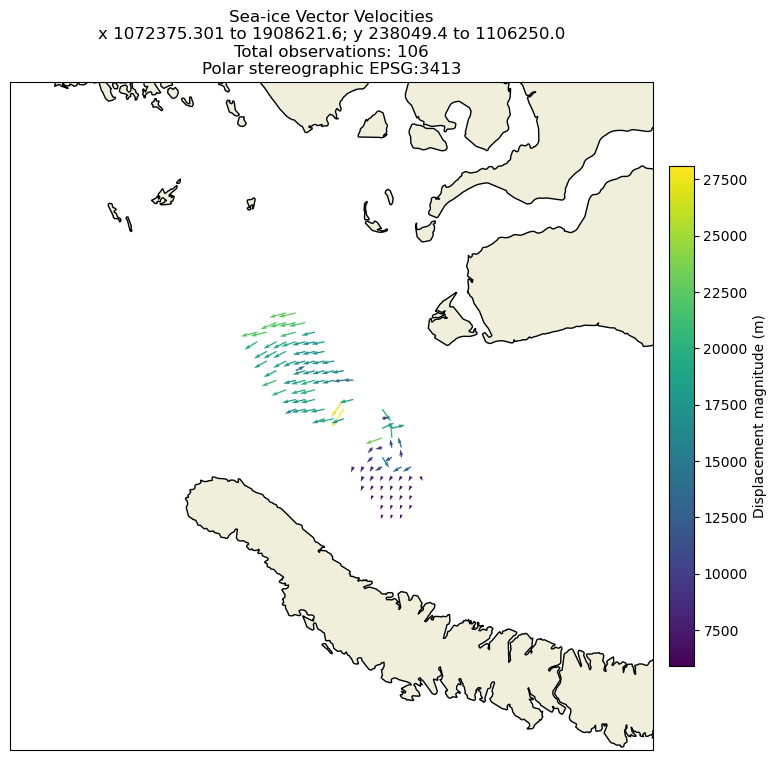

In [13]:
create_png(layer_values, has_outliers)